Análisis de componentes principales

---



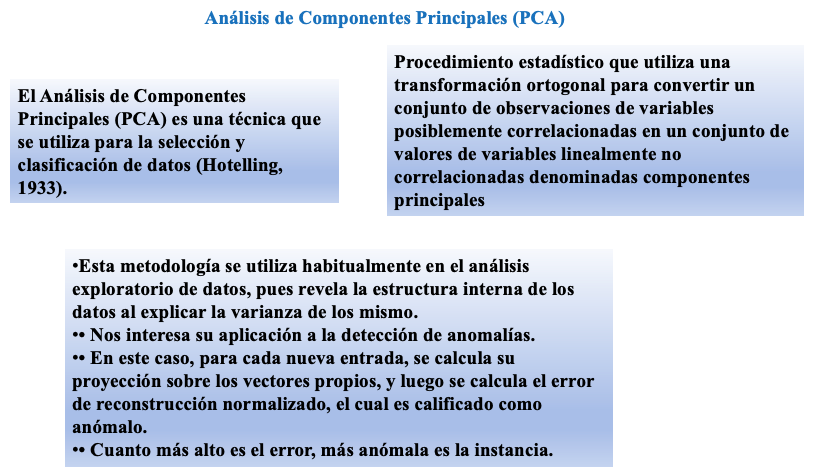

Ejemplo 1

---



In [ ]:
#paso 1 - importar módulos de las librerías a utilizar
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

In [ ]:
#paso 2 - importar librerías para realizar gráficos
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use("ggplot") or plt.style.use("ggplot")

In [ ]:
#paso 3 - importar laibrerías para el preprocesado y modelado de datos
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

In [ ]:
# Cargar los datos
# Cargar el dataset
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
data = pd.read_csv(url)

El dataset Carseats contiene datos simulados sobre las ventas de asientos para niños en 400 tiendas diferentes. Este conjunto de datos incluye las siguientes variables:

Sales: Ventas unitarias (en miles) en cada ubicación.

CompPrice: Precio cobrado por el competidor en cada ubicación.

Income: Nivel de ingresos de la comunidad (en miles de dólares).

Advertising: Presupuesto de publicidad local para la empresa en cada ubicación (en miles de dólares).

Population: Tamaño de la población en la región (en miles).

Price: Precio que la empresa cobra por los asientos para niños en cada sitio.

ShelveLoc: Calidad de la ubicación en los estantes para los asientos (con niveles: Malo, Bueno y Medio).

Age: Edad promedio de la población local.

Education: Nivel educativo en cada ubicación.

Urban: Indicador de si la tienda está en una zona urbana o rural.

US: Indicador de si la tienda está en los EE. UU. o no.

In [ ]:
# Seleccionar las variables numéricas
features = ['Price', 'Advertising', 'Income', 'Population', 'Age', 'Education']
X = data[features]
X

,Price,Advertising,Income,Population,Age,Education
0,120,11,73,276,42,17
1,83,16,48,260,65,10
2,80,10,35,269,59,12
3,97,4,100,466,55,14
4,128,3,64,340,38,13
...,...,...,...,...,...,...
395,128,17,108,203,33,14
396,120,3,23,37,55,11
397,159,12,26,368,40,18
398,95,7,79,284,50,12


In [ ]:
y=data['Sales']
y

,Sales
0,9.50
1,11.22
2,10.06
3,7.40
4,4.15
...,...
395,12.57
396,6.14
397,7.41
398,5.94


In [ ]:
# Preprocesamiento de datos - Hacemos el escalamiento

x_scaled = StandardScaler().fit_transform(X)
x_scaled

array([[ 0.17782345,  0.65717702,  0.15536099,  0.07581929, -0.69978222,
         1.18444912],
       [-1.38685375,  1.40995711, -0.73906037, -0.0328822 ,  0.72172284,
        -1.4901134 ],
       [-1.51371947,  0.506621  , -1.20415947,  0.02826239,  0.35089544,
        -0.72595268],
       ...,
       [ 1.82707779,  0.80773304, -1.52615116,  0.70085283, -0.82339136,
         1.56652948],
       [-0.87939087,  0.05495295,  0.37002211,  0.13017003, -0.20534568,
        -0.72595268],
       [ 0.17782345, -0.99893918, -1.13260576, -1.61584759, -0.26715025,
         0.80236876]])

In [ ]:
# Aplicamos el método de PCA para reducir la dimensionalidad
#seleccionamos componentes y le pedimos que haga la transformación
#a partir de los datos escalados

pca = PCA()
pca_features = pca.fit_transform(x_scaled)

In [ ]:
# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2','PC3', 'PC4','PC5', 'PC6'])
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6
0,0.216348,0.726584,-0.218377,1.239088,-0.444698,-0.174607
1,1.058513,-1.371643,-0.690794,-1.145428,-0.131927,-1.546446
2,0.244060,-0.913468,-0.951392,-1.101174,-0.836397,-0.968332
3,0.744708,-1.054885,0.341071,0.380123,-0.626430,1.267216
4,0.234639,0.867057,0.587545,-0.511449,-0.397769,0.545534
...,...,...,...,...,...,...
395,1.121102,0.534877,1.318740,1.430435,0.155730,-1.042076
396,-1.271253,0.462978,-0.113588,-1.793487,0.355497,-1.203158
397,0.478178,2.694384,-1.417826,0.640322,0.069096,0.172012
398,0.378890,-0.800503,0.515726,-0.347409,-0.528515,-0.221415


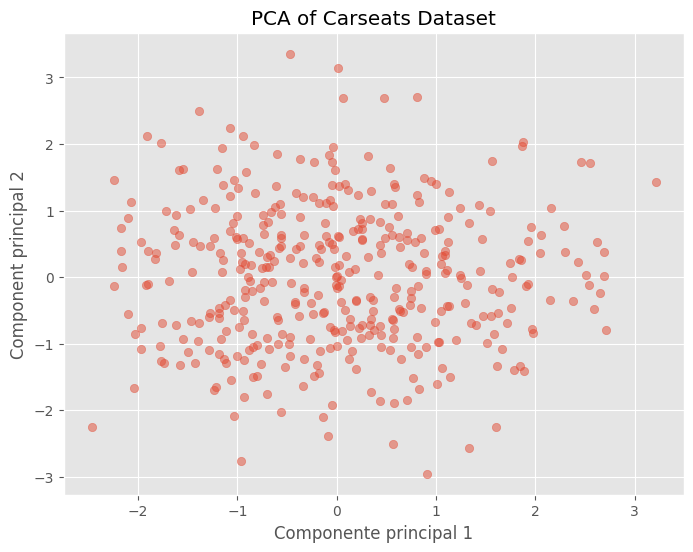

In [ ]:
# Visualizar los componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.xlabel('Componente principal 1')
plt.ylabel('Component principal 2')
plt.title('PCA of Carseats Dataset')
plt.show()


In [ ]:
#miramos el ratio de variabilidad explicada por cada componente
print("El porcentaje de varianza explicada por cada componente es: ",
      pca.explained_variance_ratio_)

El porcentaje de varianza explicada por cada componente es:  [0.21878279 0.18673577 0.16875669 0.15934438 0.14993343 0.11644696]


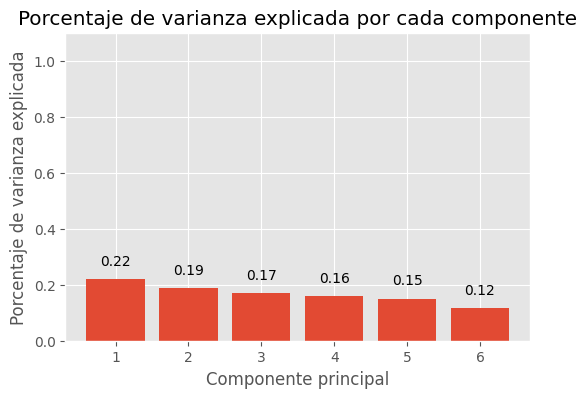

In [ ]:
#lo graficamos:
fig, ax=plt.subplots(nrows=1,ncols=1,figsize=(6,4))#6 filas , 4 columnas
ax.bar(
    x=np.arange(pca.n_components_)+1,
    height=pca.explained_variance_ratio_
)
for x,y in zip(np.arange(len(data.columns))+1,pca.explained_variance_ratio_):
  label=round(y,2)
  ax.annotate(
      label,
      (x,y),
      textcoords="offset points",
      xytext=(0,10),
      ha="center"
  )
  ax.set_xticks(np.arange(pca.n_components_)+1)
  ax.set_ylim(0,1.1)
  ax.set_title("Porcentaje de varianza explicada por cada componente")
  ax.set_xlabel("Componente principal")
  ax.set_ylabel("Porcentaje de varianza explicada")

In [ ]:
#vemos el porcentaje de varianza explicada acumulada
varianza_acumulada=pca.explained_variance_ratio_.cumsum()
print("El porcentaje de varianza explicada acumulada es: ", varianza_acumulada)

El porcentaje de varianza explicada acumulada es:  [0.21878279 0.40551855 0.57427524 0.73361962 0.88355304 1.        ]


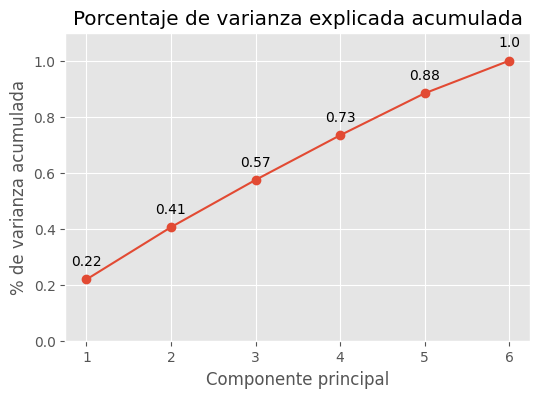

In [ ]:
#lo graficamos:
fig, ax=plt.subplots(nrows=1,ncols=1,figsize=(6,4))
ax.plot(
    np.arange(pca.n_components_) + 1,
    varianza_acumulada,
    marker="o"
)
for x,y in zip(np.arange(pca.n_components_) + 1, varianza_acumulada):
  label=round(y,2)
  ax.annotate(
      label,
      (x,y),
      textcoords="offset points",
      xytext=(0,10),
      ha="center"
  )
  ax.set_ylim(0,1.1)
  ax.set_xticks(np.arange(pca.n_components_) + 1)
  ax.set_title("Porcentaje de varianza explicada acumulada")
  ax.set_xlabel("Componente principal")
  ax.set_ylabel("% de varianza acumulada");

In [ ]:
# Aplicamos el método de PCA para reducir la dimensionalidad
#seleccionamos 4 componentes y le pedimos que haga la transformación
#a partir de los datos escalados

pca = PCA(n_components=4)
pca_features = pca.fit_transform(x_scaled)

In [ ]:
# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2','PC3','PC4'])
pca_df

,PC1,PC2,PC3,PC4
0,0.216348,0.726584,-0.218377,1.239088
1,1.058513,-1.371643,-0.690794,-1.145428
2,0.244060,-0.913468,-0.951392,-1.101174
3,0.744708,-1.054885,0.341071,0.380123
4,0.234639,0.867057,0.587545,-0.511449
...,...,...,...,...
395,1.121102,0.534877,1.318740,1.430435
396,-1.271253,0.462978,-0.113588,-1.793487
397,0.478178,2.694384,-1.417826,0.640322
398,0.378890,-0.800503,0.515726,-0.347409


In [ ]:
#miramos el ratio de variabilidad explicada por cada componente
print("El porcentaje de varianza explicada por cada componente es: ",
      pca.explained_variance_ratio_)

El porcentaje de varianza explicada por cada componente es:  [0.21878279 0.18673577 0.16875669 0.15934438]


In [ ]:
#agregamos los datos de la variable explicada
pca_df['Ventas'] = data["Sales"]
pca_df

,PC1,PC2,PC3,PC4,Ventas
0,0.216348,0.726584,-0.218377,1.239088,9.50
1,1.058513,-1.371643,-0.690794,-1.145428,11.22
2,0.244060,-0.913468,-0.951392,-1.101174,10.06
3,0.744708,-1.054885,0.341071,0.380123,7.40
4,0.234639,0.867057,0.587545,-0.511449,4.15
...,...,...,...,...,...
395,1.121102,0.534877,1.318740,1.430435,12.57
396,-1.271253,0.462978,-0.113588,-1.793487,6.14
397,0.478178,2.694384,-1.417826,0.640322,7.41
398,0.378890,-0.800503,0.515726,-0.347409,5.94


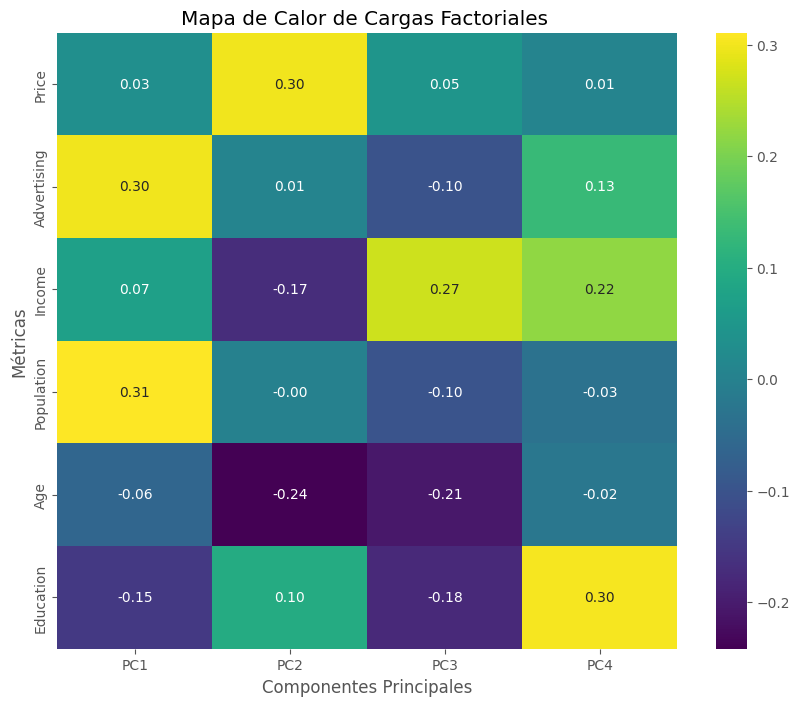

In [ ]:
import seaborn as sns
# Calcula las Cargas Factoriales para todos los componentes
loadings = pca.components_.T * np.sqrt(pca.explained_variance_ratio_)


loadings_df = pd.DataFrame(loadings, index=features, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# Mostramos Cargas Factoriales
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, annot=True, cmap='viridis', fmt=".2f")
plt.title('Mapa de Calor de Cargas Factoriales ')
plt.xlabel('Componentes Principales')
plt.ylabel('Métricas')
plt.show()

Ejemplo 2

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reemplazar con 'Tu_Carpeta/tu_dataset.csv' con la ruta real de tu archivo en Google Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/Taller de programación/crypto_metrics.csv'
df = pd.read_csv(file_path)

df

,coin,volatility,liquidity,max_drawdown,market_cap,age
0,Bitcoin,0.064226,33182009070,0.236646,2241685418265,6056
1,Ethereum,0.131053,27684741311,0.551584,410830923425,3657
2,XRP,0.129846,6646034445,0.469216,165228747378,365
3,Tether,0.001084,68142343377,0.001241,163854374085,365
4,BNB,0.079374,1235127485,0.316967,102853681381,2948
5,Solana,0.135935,4626383045,0.373265,85496319358,365
6,USDC,0.000835,10055291522,0.000517,64182252899,365
7,TRON,0.074014,1381341229,0.295966,30467500076,2897
8,Lido Staked Ether,0.132987,61983228,0.551375,30463822909,365
9,Dogecoin,0.172444,2219770457,0.483479,28853925870,4256


In [ ]:
# Seleccionar las variables numéricas
features = ['volatility', 'liquidity', 'max_drawdown', 'age']
X = df[features]

In [ ]:
# Preprocesamiento de datos - Hacemos el escalamiento

x_scaled = StandardScaler().fit_transform(X)

In [ ]:
# Aplicamos el método de PCA para reducir la dimensionalidad
#seleccionamos componentes y le pedimos que haga la transformación
#a partir de los datos escalados

pca = PCA()
pca_features = pca.fit_transform(x_scaled)

In [ ]:
# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2','PC3', 'PC4'])
pca_df

,PC1,PC2,PC3,PC4
0,-2.475468,2.431197,-0.038488,0.016449
1,-0.246610,1.641264,1.023176,-0.415784
2,0.461773,-0.483246,0.254218,-0.146351
3,-4.436367,-1.015230,1.791782,0.125269
4,-0.716539,0.579971,-0.991661,-0.166472
5,0.262909,-0.594730,0.000470,0.318440
6,-2.646931,-1.460460,-1.217579,0.077040
7,-0.845591,0.508738,-1.047993,-0.151488
8,0.979790,-0.423160,0.089582,-0.442892
9,0.693816,1.841728,-0.274411,0.380317


In [ ]:
#miramos el ratio de variabilidad explicada por cada componente
print("El porcentaje de varianza explicada por cada componente es: ",
      pca.explained_variance_ratio_)

El porcentaje de varianza explicada por cada componente es:  [0.61233072 0.24581346 0.12105148 0.02080434]


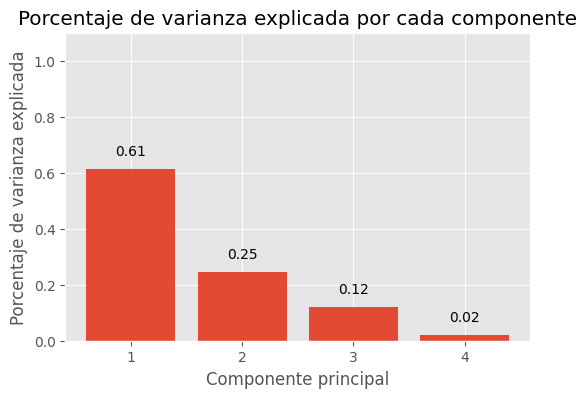

In [ ]:
#lo graficamos:
fig, ax=plt.subplots(nrows=1,ncols=1,figsize=(6,4))#6 filas , 4 columnas
ax.bar(
    x=np.arange(pca.n_components_)+1,
    height=pca.explained_variance_ratio_
)
for x,y in zip(np.arange(len(df.columns))+1,pca.explained_variance_ratio_):
  label=round(y,2)
  ax.annotate(
      label,
      (x,y),
      textcoords="offset points",
      xytext=(0,10),
      ha="center"
  )
  ax.set_xticks(np.arange(pca.n_components_)+1)
  ax.set_ylim(0,1.1)
  ax.set_title("Porcentaje de varianza explicada por cada componente")
  ax.set_xlabel("Componente principal")
  ax.set_ylabel("Porcentaje de varianza explicada")

In [ ]:
#vemos el porcentaje de varianza explicada acumulada
varianza_acumulada=pca.explained_variance_ratio_.cumsum()
print("El porcentaje de varianza explicada acumulada es: ", varianza_acumulada)

El porcentaje de varianza explicada acumulada es:  [0.61233072 0.85814418 0.97919566 1.        ]


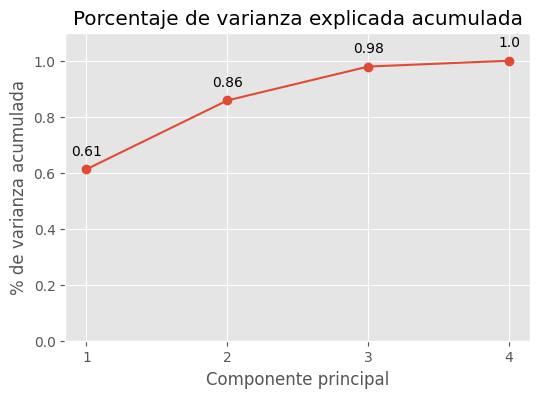

In [ ]:
#lo graficamos:
fig, ax=plt.subplots(nrows=1,ncols=1,figsize=(6,4))
ax.plot(
    np.arange(pca.n_components_) + 1,
    varianza_acumulada,
    marker="o"
)
for x,y in zip(np.arange(pca.n_components_) + 1, varianza_acumulada):
  label=round(y,2)
  ax.annotate(
      label,
      (x,y),
      textcoords="offset points",
      xytext=(0,10),
      ha="center"
  )
  ax.set_ylim(0,1.1)
  ax.set_xticks(np.arange(pca.n_components_) + 1)
  ax.set_title("Porcentaje de varianza explicada acumulada")
  ax.set_xlabel("Componente principal")
  ax.set_ylabel("% de varianza acumulada")

In [ ]:
# Generamos loadings
loadings = pca.components_

# Creamos un DataFrame con los loadings
loadings_df = pd.DataFrame(loadings, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])

# Display the loadings
print("Cargas factoriales de los componentes principales:")
display(loadings_df)

Cargas factoriales de los componentes principales:


,volatility,liquidity,max_drawdown,age
PC1,0.597758,-0.508432,0.592976,-0.180448
PC2,0.184812,0.125651,0.211013,0.951593
PC3,0.318191,0.851777,0.334007,-0.248333
PC4,0.712239,0.013576,-0.701635,0.015467


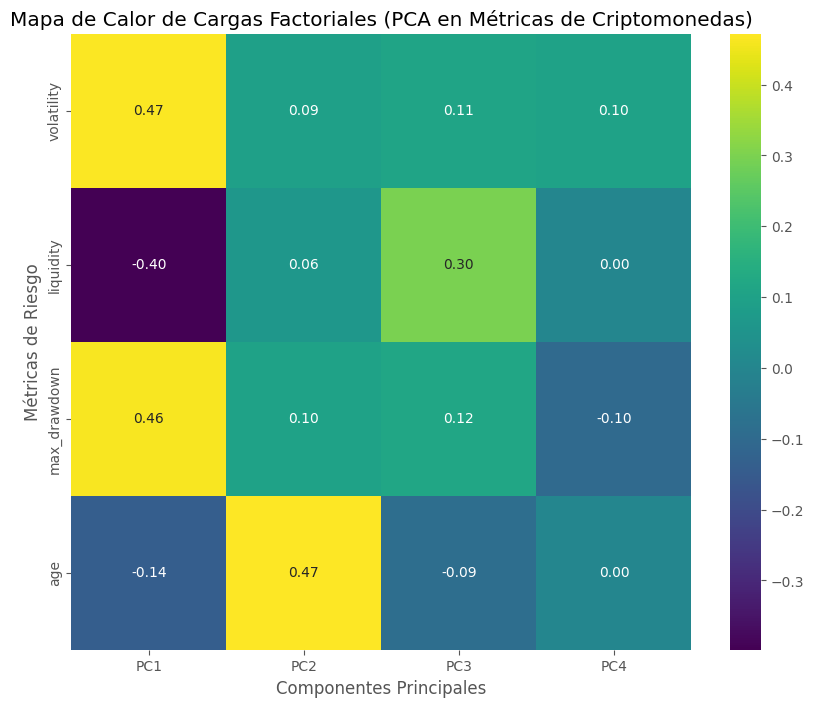

In [ ]:
# Calcular Cargas Factoriales para todos los componentes
loadings = pca.components_.T * np.sqrt(pca.explained_variance_ratio_)

loadings_df = pd.DataFrame(loadings, index=features, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, annot=True, cmap='viridis', fmt=".2f")
plt.title('Mapa de Calor de Cargas Factoriales (PCA en Métricas de Criptomonedas)')
plt.xlabel('Componentes Principales')
plt.ylabel('Métricas de Riesgo')
plt.show()

pca con 2 componentes retenidos

---



In [ ]:
# Seleccionar las variables numéricas
features = ['volatility', 'liquidity', 'max_drawdown', 'age']
X = df[features]

In [ ]:
# Preprocesamiento de datos - Hacemos el escalamiento

x_scaled = StandardScaler().fit_transform(X)

In [ ]:
# Aplicamos el método de PCA para reducir la dimensionalidad
#seleccionamos componentes y le pedimos que haga la transformación
#a partir de los datos escalados

pca = PCA(n_components=2)
pca_features = pca.fit_transform(x_scaled)

In [ ]:
# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,-2.475468,2.431197
1,-0.246610,1.641264
2,0.461773,-0.483246
3,-4.436367,-1.015230
4,-0.716539,0.579971


In [ ]:
#miramos el ratio de variabilidad explicada por cada componente
print("El porcentaje de varianza explicada por cada componente es: ",
      pca.explained_variance_ratio_)
#vemos el porcentaje de varianza explicada acumulada
varianza_acumulada=pca.explained_variance_ratio_.cumsum()
print("El porcentaje de varianza explicada acumulada es: ", varianza_acumulada)

El porcentaje de varianza explicada por cada componente es:  [0.61233072 0.24581346]
El porcentaje de varianza explicada acumulada es:  [0.61233072 0.85814418]


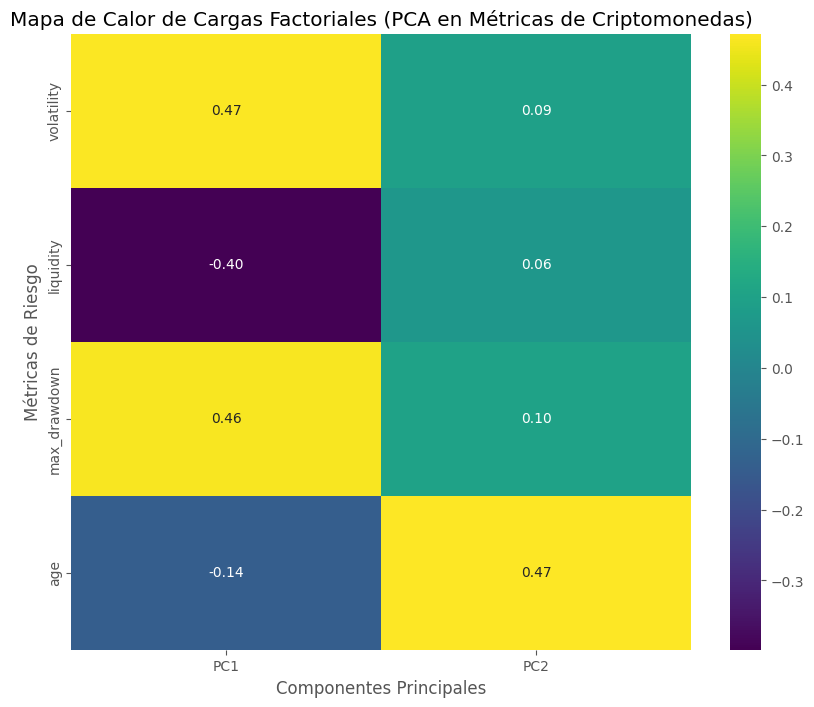

In [ ]:
# Calcular Cargas Factoriales para todos los componentes

loadings = pca.components_.T * np.sqrt(pca.explained_variance_ratio_)

#hacemos un dataframe
loadings_df = pd.DataFrame(loadings, index=features, columns=[f'PC{i+1}' for i in range(pca.n_components_)])


plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, annot=True, cmap='viridis', fmt=".2f")
plt.title('Mapa de Calor de Cargas Factoriales (PCA en Métricas de Criptomonedas)')
plt.xlabel('Componentes Principales')
plt.ylabel('Métricas de Riesgo')
plt.show()

Entrenamiento no supervisado

Clustering

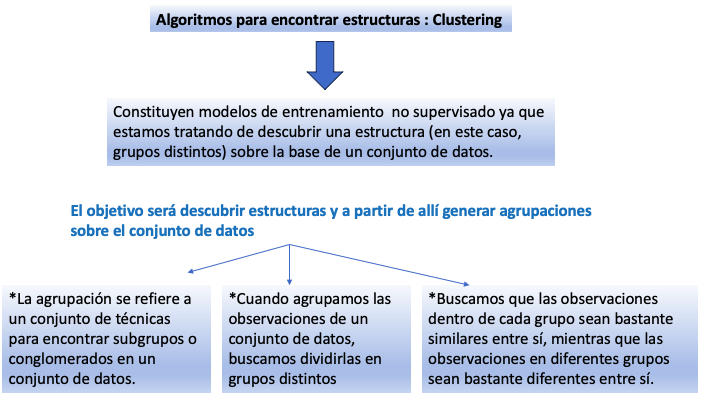

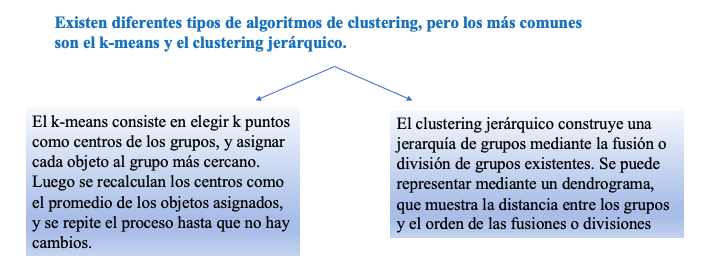

Ejemplo 4 - agrupamiento de activos

---



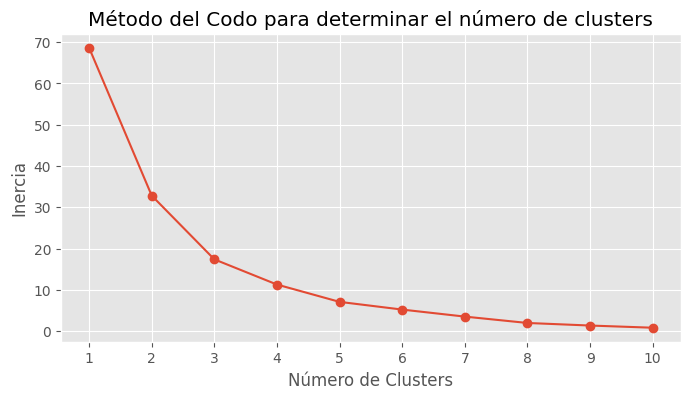

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


X_for_clustering = pca_df.copy()

# Elbow
inertia = []
range_n_clusters = range(1, 11)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_for_clustering)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Método del Codo para determinar el número de clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

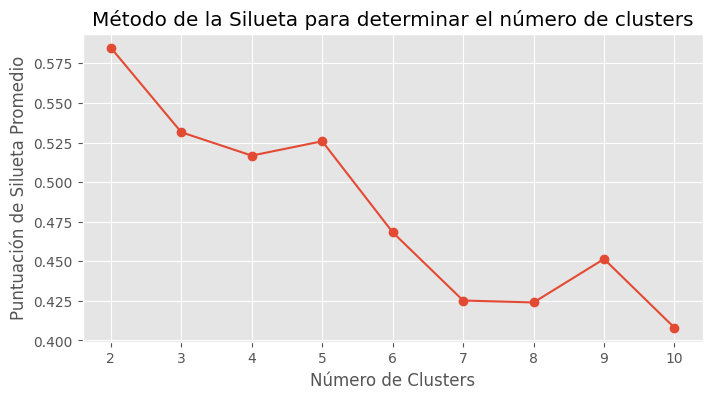

In [ ]:

from sklearn.metrics import silhouette_score


# Silhouette
silhouette_scores = []
range_n_clusters = range(2, 11)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_for_clustering)
    silhouette_avg = silhouette_score(X_for_clustering, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Método de la Silueta para determinar el número de clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Puntuación de Silueta Promedio')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

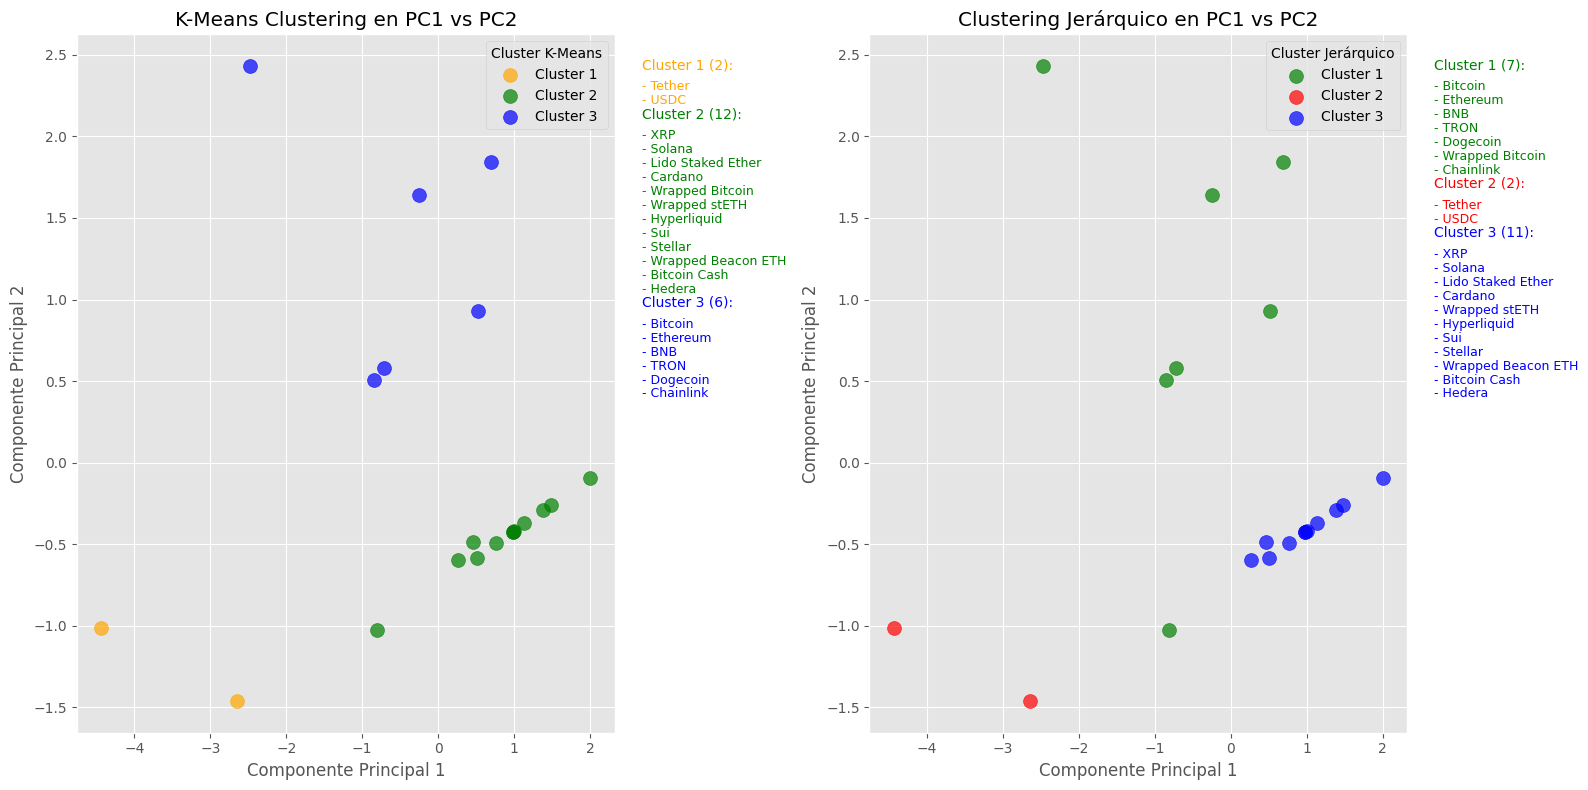

In [ ]:
# Realizamos un K-Means para k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(pca_df)

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_clusters = hierarchical.fit_predict(pca_df)


# agregamos los clusteres en el DataFrame
df['kmeans_cluster'] = kmeans.labels_
df['hierarchical_cluster'] = hierarchical_clusters


# graficamos
plt.figure(figsize=(16, 8))

# K-Means
plt.subplot(1, 2, 1)

colors = ['orange', 'green', 'blue']
for cluster_id in sorted(df['kmeans_cluster'].unique()):
    cluster_df = df[df['kmeans_cluster'] == cluster_id]
    plt.scatter(pca_features[cluster_df.index, 0], pca_features[cluster_df.index, 1],
                color=colors[cluster_id % len(colors)], label=f'Cluster {cluster_id + 1}', s=100, alpha=0.7)
plt.title('K-Means Clustering en PC1 vs PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster K-Means')
plt.grid(True)


y_text_offset = 0.95
for cluster_id in sorted(df['kmeans_cluster'].unique()):
    cluster_coins = df[df['kmeans_cluster'] == cluster_id]['coin'].tolist()
    text_color = colors[cluster_id % len(colors)]
    plt.text(1.05, y_text_offset, f'Cluster {cluster_id + 1} ({len(cluster_coins)}):', transform=plt.gca().transAxes, fontsize=10, color=text_color, ha='left') # Add 1 to cluster_id for text
    y_text_offset -= 0.03
    for coin_name in cluster_coins:
        plt.text(1.05, y_text_offset, f'- {coin_name}', transform=plt.gca().transAxes, fontsize=9, color=text_color, ha='left')
        y_text_offset -= 0.02


# Hierarchical Clustering
plt.subplot(1, 2, 2)

colors = ['green', 'red', 'blue']
for cluster_id in sorted(df['hierarchical_cluster'].unique()):
    cluster_df = df[df['hierarchical_cluster'] == cluster_id]
    plt.scatter(pca_features[cluster_df.index, 0], pca_features[cluster_df.index, 1],
                color=colors[cluster_id % len(colors)], label=f'Cluster {cluster_id + 1}', s=100, alpha=0.7)
plt.title('Clustering Jerárquico en PC1 vs PC2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster Jerárquico')
plt.grid(True)


y_text_offset = 0.95
for cluster_id in sorted(df['hierarchical_cluster'].unique()):
    cluster_coins = df[df['hierarchical_cluster'] == cluster_id]['coin'].tolist()
    text_color = colors[cluster_id % len(colors)]
    plt.text(1.05, y_text_offset, f'Cluster {cluster_id + 1} ({len(cluster_coins)}):', transform=plt.gca().transAxes, fontsize=10, color=text_color, ha='left') # Add 1 to cluster_id for text
    y_text_offset -= 0.03
    for coin_name in cluster_coins:
        plt.text(1.05, y_text_offset, f'- {coin_name}', transform=plt.gca().transAxes, fontsize=9, color=text_color, ha='left')
        y_text_offset -= 0.02

plt.tight_layout()
plt.show()

In [ ]:

pca_df['Cluster'] = df['Cluster'].values
pca_df['kmeans_cluster'] = df['kmeans_cluster'].values
pca_df['hierarchical_cluster'] = df['hierarchical_cluster'].values

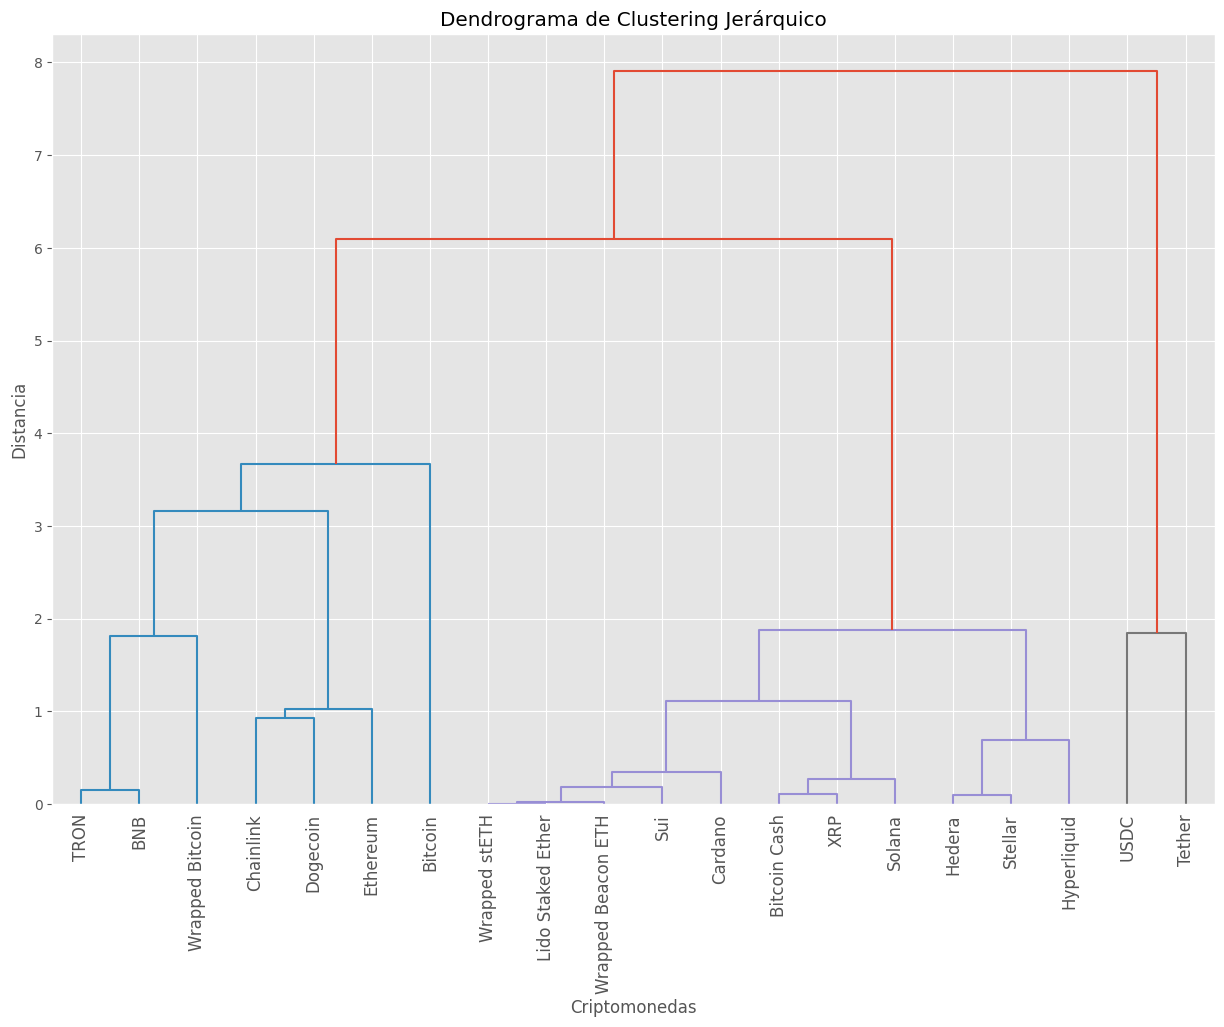

In [ ]:
# Dendrograma - Hierarchical Clustering
plt.figure(figsize=(15, 10))
linked = linkage(pca_features[:, :2], 'ward')
dendrogram(linked,
            orientation='top',
            labels=df['coin'].tolist(),
            distance_sort='descending',
            show_leaf_counts=True)
plt.title('Dendrograma de Clustering Jerárquico')
plt.ylabel('Distancia')
plt.xlabel('Criptomonedas')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Comparamos K-Means con Hierarchical clusters
comparison_crosstab = pd.crosstab(df['Cluster'], df['hierarchical_cluster'])

print("Comparison of K-Means Clusters and Hierarchical Clusters:")
display(comparison_crosstab)

Comparison of K-Means Clusters and Hierarchical Clusters:


hierarchical_cluster,0,1,2
Cluster,,,
0,0,2,0
1,1,0,11
2,6,0,0


In [ ]:
# Calculamos la media de cada CP para  K-Means
kmeans_pca_means = pca_df.groupby('Cluster')[['PC1', 'PC2']].mean()

print("Mean of First 4 Principal Components per K-Means Cluster:")
display(kmeans_pca_means)

# Calculamos la media de cada CP para Hierarchical cluster
hierarchical_pca_means = pca_df.groupby('hierarchical_cluster')[['PC1', 'PC2']].mean()

print("\nMean of First 4 Principal Components per Hierarchical Cluster:")
display(hierarchical_pca_means)

Mean of First 4 Principal Components per K-Means Cluster:


,PC1,PC2
Cluster,,
0,-3.541649,-1.237845
1,0.846285,-0.454521
2,-0.512021,1.321657



Mean of First 4 Principal Components per Hierarchical Cluster:


,PC1,PC2
hierarchical_cluster,,
0,-0.554842,0.986367
1,-3.541649,-1.237845
2,0.997017,-0.402625


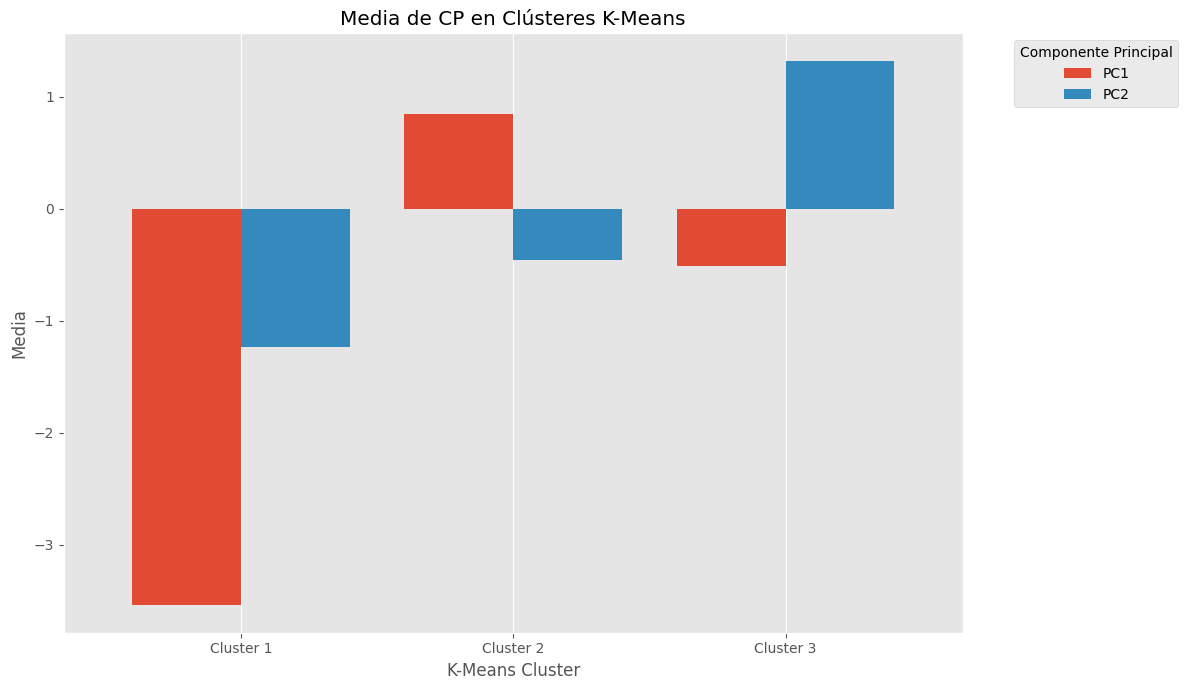

In [ ]:
# graficamos cargas factoriales por cluster k-means
ax = kmeans_pca_means.plot(kind='bar', figsize=(12, 7), width=0.8)

plt.title('Media de CP en Clústeres K-Means')
plt.xlabel('K-Means Cluster')
plt.ylabel('Media')
plt.xticks(rotation=0)

ax.set_xticklabels([f'Cluster {i+1}' for i in kmeans_pca_means.index])
plt.grid(axis='y')
plt.legend(title='Componente Principal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

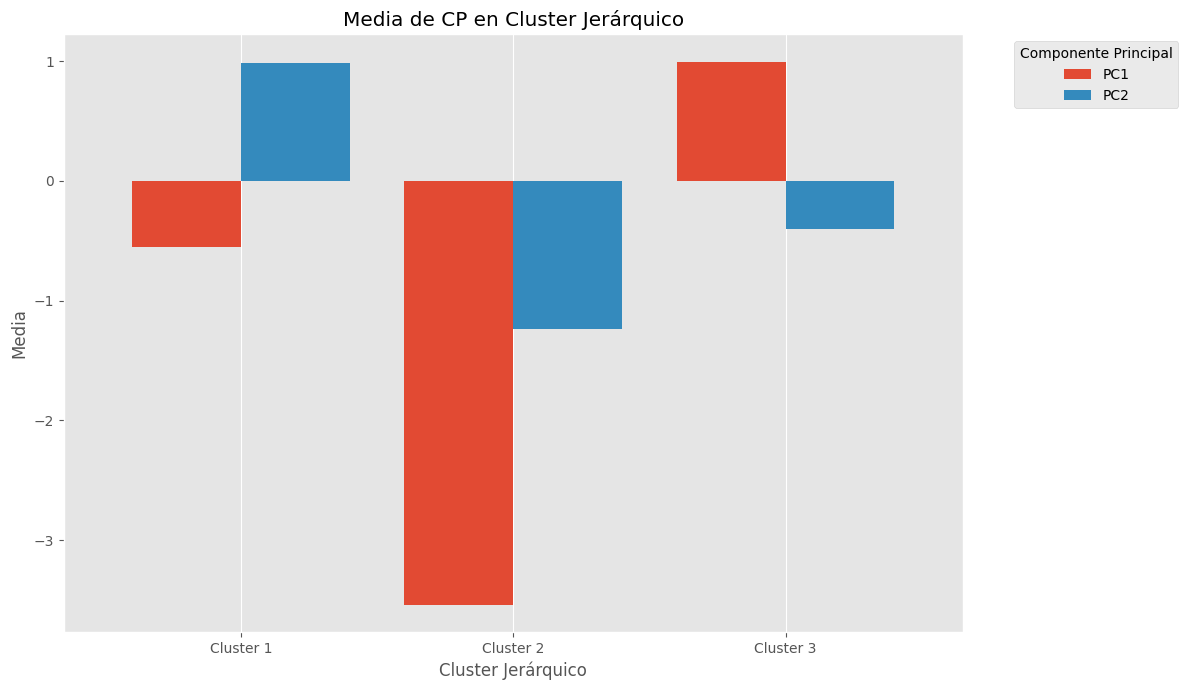

In [ ]:
# graficamos cargas factoriales por cluster jerarquico
ax = hierarchical_pca_means.plot(kind='bar', figsize=(12, 7), width=0.8)

plt.title('Media de CP en Cluster Jerárquico')
plt.xlabel('Cluster Jerárquico')
plt.ylabel('Media')
plt.xticks(rotation=0)

ax.set_xticklabels([f'Cluster {i+1}' for i in hierarchical_pca_means.index])
plt.grid(axis='y')
plt.legend(title='Componente Principal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ejemplo 5

---



In [ ]:
#Librerías a utilizar
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#usamos el dataset carseats almacenado en el objeto data
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
data = pd.read_csv(url)

In [ ]:
# Seleccionamos las variables numéricas
features = ['Price', 'Advertising', 'Income', 'Population', 'Age', 'Education']
X = data[features]

# Estandarizarmos los datos
X_standardized = (X - X.mean()) / X.std()

In [ ]:
# Aplicamos el algoritmo de K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_standardized)


In [ ]:
# Añadimos los clusters al DataFrame original
data['Cluster'] = clusters
data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,2
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,0
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,1
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,1
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,0


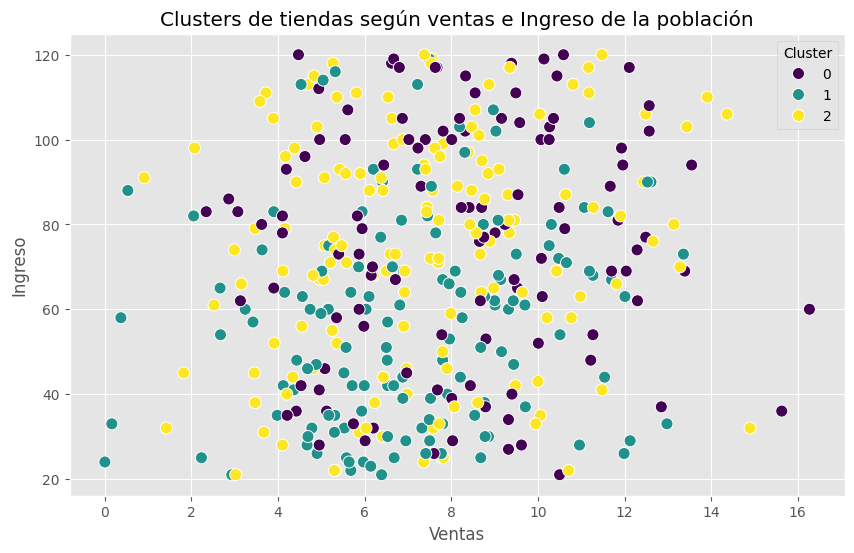

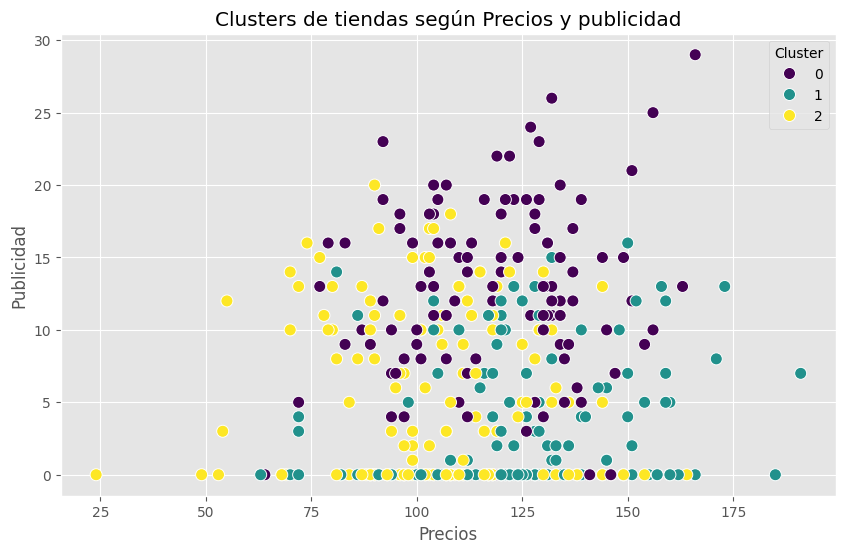

In [ ]:
#gráficos para visualizar los clusters
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Income', hue='Cluster', data=data, palette='viridis', s=75)
plt.title('Clusters de tiendas según ventas e Ingreso de la población')
plt.xlabel('Ventas')
plt.ylabel('Ingreso')
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price', y='Advertising', hue='Cluster', data=data, palette='viridis', s=75)
plt.title('Clusters de tiendas según Precios y publicidad')
plt.xlabel('Precios')
plt.ylabel('Publicidad')
plt.show()



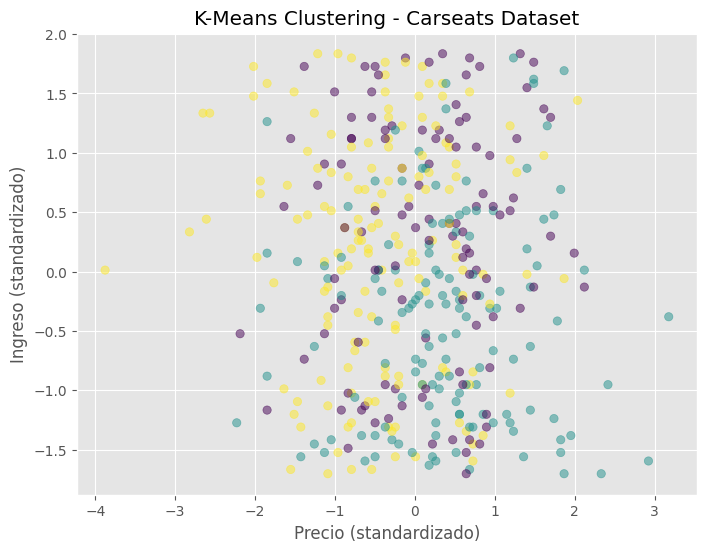

In [ ]:
# Visualizamos los clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_standardized['Price'], X_standardized['Income'], c=clusters, cmap='viridis', alpha=0.5)
plt.xlabel('Precio (standardizado)')
plt.ylabel('Ingreso (standardizado)')
plt.title('K-Means Clustering - Carseats Dataset')
plt.show()


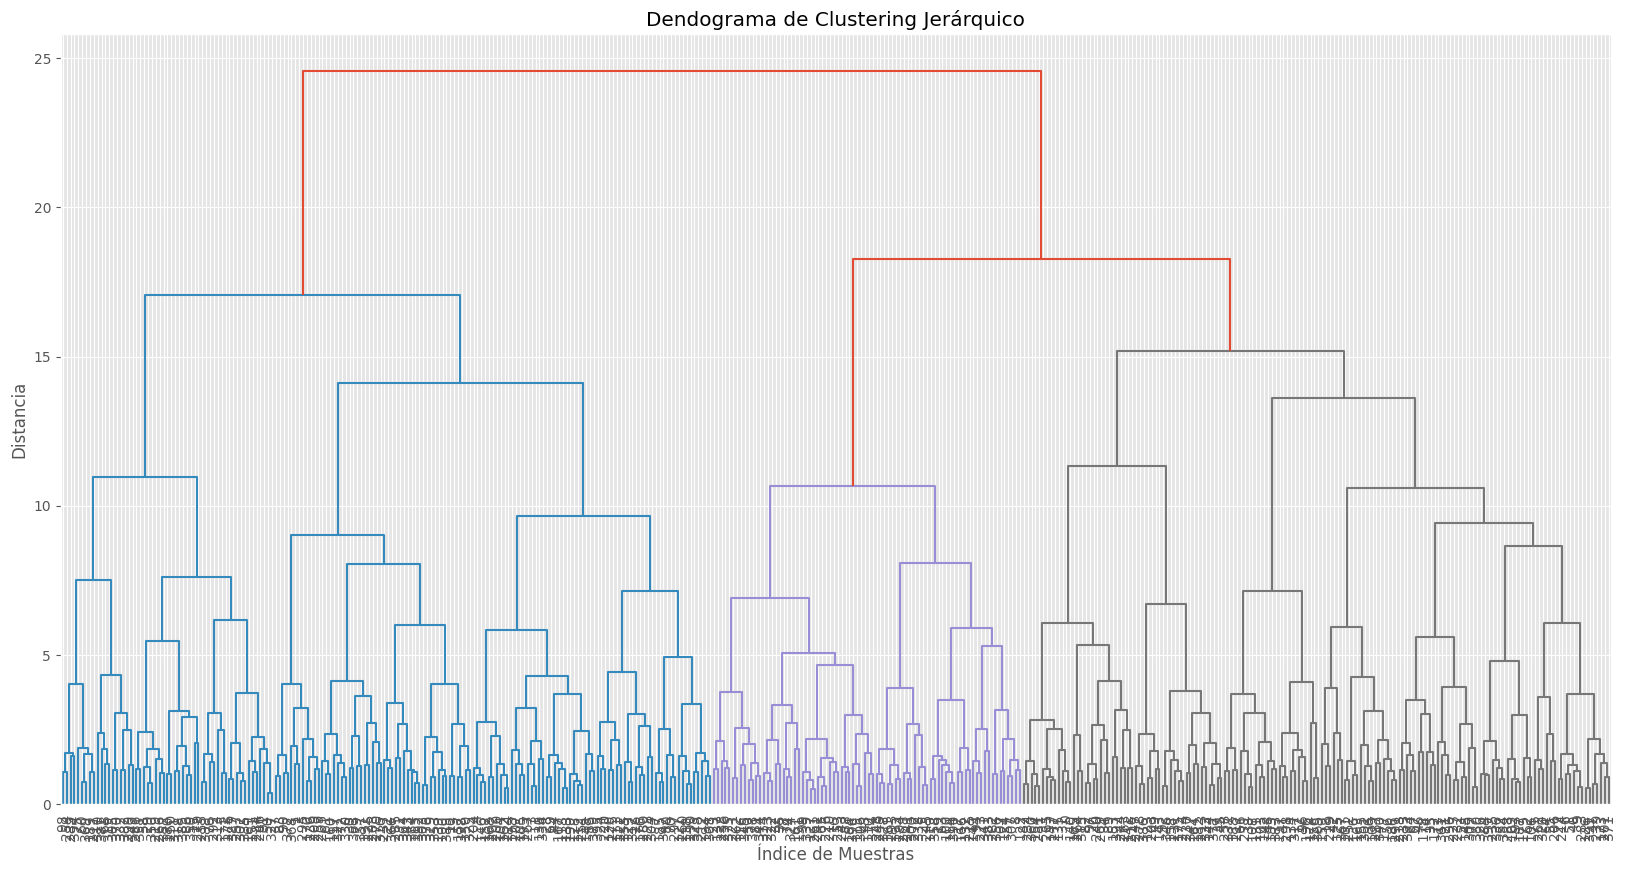

In [ ]:
#clustering jerárquico
#librerías específicas
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

#usamos el archivo data
# Seleccionar las variables numéricas
features = ['Price', 'Advertising', 'Income', 'Population', 'Age', 'Education']
X = data[features]

# Estandarizar los datos
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Aplicar clustering jerárquico
Z = linkage(X_standardized, method='ward')

# Generar el dendograma
plt.figure(figsize=(20, 10))
dendrogram(Z, labels=data.index, leaf_rotation=90, leaf_font_size=10)
plt.title('Dendograma de Clustering Jerárquico')
plt.xlabel('Índice de Muestras')
plt.ylabel('Distancia')
plt.show()


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


# Cortar el dendrograma en 3 clusters
clusters_hierarchical = fcluster(Z, t=3, criterion='maxclust')

# Agregar los clusters al DataFrame original
data['Cluster jerárquico'] = clusters_hierarchical

data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Cluster,Cluster jerárquico
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,3
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,0,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,2,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes,0,1
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes,1,2
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes,1,3
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes,0,1
